# k-Vecinos Más Cercanos : k-Nearest Neighbors (kNN)

Pamela Cerdas 

KNN predice los datos segun su vecino mas cercano, es decir ete guardas la cantidad de factores o variables y agreupa el nuevo segun su vecino más cercano

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.model_selection import train_test_split  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

#import ML

In [3]:
N=1000
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=.23, random_state=23) 

X, Y = noisy_data

print(X.shape)
print(Y.shape)

(1000, 2)
(1000,)


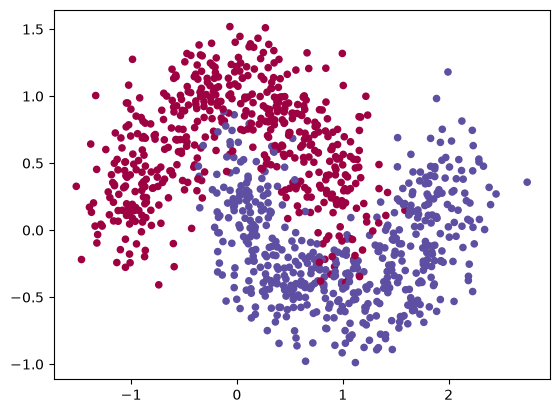

In [4]:
plt.scatter(X[:,0], X[:,1], c=Y, s=20, cmap=plt.cm.Spectral);

Visualización de los datos antes de aplicar KNN, como se observa hay 2 grupos distintos

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=.60)

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(600, 2)
(600,)
(400, 2)
(400,)


In [6]:
modelo_kNN = KNeighborsClassifier(n_neighbors=3)

modelo_kNN.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9533333333333334
0.9425


De cada 100 observaciones que realiza el modelo, es te acierta el 95%

In [7]:
for k in range(1,16):
  modelo_kNN = KNeighborsClassifier(n_neighbors=k)
  modelo_kNN.fit(X_train, Y_train)

  trs = modelo_kNN.score(X_train, Y_train)
  tes = modelo_kNN.score(X_test, Y_test)

  print('k=%d\tTrain: %.4f\tTest: %.4f' % (k, trs, tes))

k=1	Train: 1.0000	Test: 0.9300
k=2	Train: 0.9583	Test: 0.9325
k=3	Train: 0.9533	Test: 0.9425
k=4	Train: 0.9483	Test: 0.9400
k=5	Train: 0.9483	Test: 0.9400
k=6	Train: 0.9517	Test: 0.9375
k=7	Train: 0.9517	Test: 0.9400
k=8	Train: 0.9500	Test: 0.9425
k=9	Train: 0.9500	Test: 0.9375
k=10	Train: 0.9483	Test: 0.9425
k=11	Train: 0.9483	Test: 0.9450
k=12	Train: 0.9500	Test: 0.9475
k=13	Train: 0.9500	Test: 0.9375
k=14	Train: 0.9500	Test: 0.9325
k=15	Train: 0.9483	Test: 0.9350


## Grid Search : Tecnica de busqueda de malla (prueba todas las combinaciones posibles)

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
dicc_grid = {'n_neighbors':[1,3,5,7,9,11], 
              'weights':['uniform', 'distance'],  
              'metric':['euclidean', 'manhattan']}

kNN = KNeighborsClassifier()

modelo_kNN = GridSearchCV(kNN, param_grid=dicc_grid, cv=3)

modelo_kNN.fit(X_train,Y_train)

print("Los mejores parametros son %s con un score de %0.2f"
      % (modelo_kNN.best_params_, modelo_kNN.best_score_))

Los mejores parametros son {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'} con un score de 0.95


11 vecinos clasifican mejor que 3 

In [10]:
kNN2 = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance')

kNN2.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9483333333333334
0.945


## Randomized Grid Search : Tecnica de busqueda aleatoria de malla (prueba solo algunas combinaciones)

Cuando la muestra de valores es muy grande esta tecnica permite tomar una muestra manejable de estos para optimizar el proceso de busqueda 

In [11]:
from sklearn.model_selection import RandomizedSearchCV

In [12]:
dicc_grid = {'n_neighbors':[1,3,5,7,9,11,13,15,17], 
             'weights':['uniform', 'distance'],  
             'metric':['euclidean', 'manhattan'],
             'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute']
             }

kNN = KNeighborsClassifier()

modelo_kNN = RandomizedSearchCV(kNN, 
                                param_distributions= dicc_grid,    # en este ejemplo tenemos 9x2x2x4=144 combinaciones posibles.
                                cv=5,         # Cross-Validation 
                                n_iter= 20     # n_iter=total de valores que se seleccionarán del grid.
                                ) 

modelo_kNN.fit(X_train,Y_train)

print("Los mejores parametros son %s \ncon un score de %0.2f"
      % (modelo_kNN.best_params_, modelo_kNN.best_score_))

Los mejores parametros son {'weights': 'uniform', 'n_neighbors': 17, 'metric': 'manhattan', 'algorithm': 'auto'} 
con un score de 0.95


In [13]:
kNN2 = KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='distance', algorithm='brute')

kNN2.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9466666666666667
0.9425


Como resultado final, el modelo aprendio bien, esto mediante la utilizacion de 11 valores mas cercano obteniendo una precisión del 94.67%.